# vR.1.5 — ETASR Ablation Study: Learning Rate Scheduler

**Base paper:** Gorle, R. & Guttavelli, A. (2025). *Enhanced Image Tampering Detection using Error Level Analysis and a CNN.* ETASR, Vol. 15, No. 1.

**Parent version:** vR.1.4 (BatchNormalization — NEUTRAL)

**Change in this version:** Add ReduceLROnPlateau learning rate scheduler
- Monitors val_loss; halves LR when validation loss plateaus for 3 epochs
- Allows finer convergence after initial rapid training
- Expected to extend training and improve final metrics

**Pipeline:** `Raw Image -> RGB -> ELA (Q=90) -> Resize 128x128 -> Normalize [0,1] -> CNN+BN -> Softmax (weighted loss + LR schedule) -> {Authentic, Tampered}`

---

### Table of Contents

1. [Version Change Log](#1-version-change-log)
2. [Imports and Configuration](#2-imports-and-configuration)
3. [Dataset Preparation](#3-dataset-preparation)
4. [ELA Preprocessing](#4-ela-preprocessing)
5. [ELA Visualization](#5-ela-visualization)
6. [Data Splitting](#6-data-splitting)
7. [Model Architecture](#7-model-architecture)
8. [Training Pipeline](#8-training-pipeline)
9. [Test Set Evaluation](#9-test-set-evaluation)
10. [Results Visualization](#10-results-visualization)
11. [Ablation Comparison](#11-ablation-comparison)
12. [Discussion](#12-discussion)

---

## 1. Version Change Log

| Parameter | vR.1.4 (Parent) | vR.1.5 (This Version) |
|-----------|-----------------|----------------------|
| LR Schedule | None (fixed lr=0.0001) | **ReduceLROnPlateau(val_loss, factor=0.5, patience=3, min_lr=1e-6)** |
| Callbacks | EarlyStopping only | EarlyStopping + **ReduceLROnPlateau** |

### What DID NOT change (frozen)
- ELA quality: 90
- Image size: 128x128
- CNN filter config: 2xConv2D(32, 5x5, valid, ReLU)
- BatchNormalization after each Conv2D (from vR.1.4)
- Optimizer: Adam(lr=0.0001)
- Loss: categorical_crossentropy
- Batch size: 32
- Early stopping: patience=5 on val_accuracy
- Seed: 42
- Data split: 70/15/15 train/val/test (stratified)
- Class weights: inverse-frequency balanced (from vR.1.3)
- No data augmentation

### Cumulative changes from baseline (vR.1.0)
1. **vR.1.1:** 70/15/15 split, per-class metrics, ROC-AUC, ELA viz, model save
2. ~~**vR.1.2:** Data augmentation~~ (REJECTED)
3. **vR.1.3:** Class weights (inverse-frequency balanced)
4. **vR.1.4:** BatchNormalization after each Conv2D
5. **vR.1.5:** ReduceLROnPlateau learning rate scheduler (this version)

In [1]:
# ============================================================
# 2.1 — Imports and Configuration
# ============================================================

import os
import random
import warnings
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization  # NEW in vR.1.4
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # NEW in vR.1.5
from tensorflow.keras.metrics import Precision, Recall

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Version Info ----
VERSION = 'vR.1.5'
CHANGE = 'LR Scheduler: add ReduceLROnPlateau(monitor=val_loss, factor=0.5, patience=3, min_lr=1e-6)'

# ---- Hyperparameters (FROZEN from baseline) ----
IMAGE_SIZE = (128, 128)
ELA_QUALITY = 90
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.0001
EARLY_STOP_PATIENCE = 5

# ---- Split ratios (FROZEN from vR.1.1) ----
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

print(f'Version: {VERSION}')
print(f'Change:  {CHANGE}')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
if len(tf.config.list_physical_devices("GPU")) > 0:
    print(f'GPU: {tf.config.list_physical_devices("GPU")[0]}')
print(f'\nConfiguration (frozen from baseline):')
print(f'  Image size:    {IMAGE_SIZE}')
print(f'  ELA quality:   {ELA_QUALITY}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Max epochs:    {EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Early stop:    patience={EARLY_STOP_PATIENCE}')
print(f'  Split:         70% train / 15% val / 15% test')
print(f'  Class weights: inverse-frequency balanced (from vR.1.3)')
print(f'  BatchNorm:     after each Conv2D (from vR.1.4)')
print(f'\nNEW in this version:')
print(f'  ReduceLROnPlateau(monitor=val_loss, factor=0.5, patience=3, min_lr=1e-6)')

2026-03-14 20:52:36.359918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773521556.576547      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773521556.632669      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773521557.090164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773521557.090209      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773521557.090212      55 computation_placer.cc:177] computation placer alr

Version: vR.1.5
Change:  LR Scheduler: add ReduceLROnPlateau(monitor=val_loss, factor=0.5, patience=3, min_lr=1e-6)
TensorFlow version: 2.19.0
GPU available: True
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Configuration (frozen from baseline):
  Image size:    (128, 128)
  ELA quality:   90
  Batch size:    32
  Max epochs:    50
  Learning rate: 0.0001
  Early stop:    patience=5
  Split:         70% train / 15% val / 15% test
  Class weights: inverse-frequency balanced (from vR.1.3)
  BatchNorm:     after each Conv2D (from vR.1.4)

NEW in this version:
  ReduceLROnPlateau(monitor=val_loss, factor=0.5, patience=3, min_lr=1e-6)


---

## 3. Dataset Preparation

In [2]:
# ============================================================
# 3.1 — Dataset Path Discovery
# ============================================================

def find_dataset():
    """Search /kaggle/input/ for Au/ and Tp/ directories."""
    search_roots = ['/kaggle/input', '/content/drive/MyDrive']
    for base in search_roots:
        if not os.path.isdir(base):
            continue
        for dirpath, dirnames, _ in os.walk(base):
            if 'Au' in dirnames and 'Tp' in dirnames:
                return dirpath, os.path.join(dirpath, 'Au'), os.path.join(dirpath, 'Tp')
    return None, None, None

DATASET_ROOT, AU_DIR, TP_DIR = find_dataset()

if DATASET_ROOT is None:
    for base in ['/kaggle/input']:
        if os.path.isdir(base):
            print(f'Contents of {base}:')
            for dirpath, dirnames, filenames in os.walk(base):
                depth = dirpath.replace(base, '').count(os.sep)
                print(f'{"  " * depth}{os.path.basename(dirpath)}/')
                if depth >= 2:
                    break
    raise FileNotFoundError('Could not find Au/ and Tp/ directories.')

SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

print(f'Dataset root: {DATASET_ROOT}')
print(f'Authentic dir: {AU_DIR}  ({len(os.listdir(AU_DIR))} files)')
print(f'Tampered dir:  {TP_DIR}  ({len(os.listdir(TP_DIR))} files)')

Dataset root: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2
Authentic dir: /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Au  (7492 files)
Tampered dir:  /kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2/Tp  (5125 files)


In [3]:
# ============================================================
# 3.2 — Collect Image Paths and Labels
# ============================================================

def collect_image_paths(directory, label, extensions=SUPPORTED_EXTENSIONS):
    """Collect all image paths with supported extensions."""
    paths, labels = [], []
    for fname in sorted(os.listdir(directory)):
        if os.path.splitext(fname)[1].lower() in extensions:
            paths.append(os.path.join(directory, fname))
            labels.append(label)
    return paths, labels

au_paths, au_labels = collect_image_paths(AU_DIR, label=0)
tp_paths, tp_labels = collect_image_paths(TP_DIR, label=1)

all_paths = au_paths + tp_paths
all_labels = au_labels + tp_labels

print(f'Authentic images: {len(au_paths)}')
print(f'Tampered images:  {len(tp_paths)}')
print(f'Total images:     {len(all_paths)}')
print(f'Class ratio (Au/Tp): {len(au_paths)/max(len(tp_paths),1):.2f}')

Authentic images: 7491
Tampered images:  5123
Total images:     12614
Class ratio (Au/Tp): 1.46


---

## 4. ELA Preprocessing

**Error Level Analysis (ELA)** re-saves an image as JPEG at quality 90 and computes the pixel-wise absolute difference. Tampered regions with different compression histories appear brighter in the ELA map.

```
I_ELA(x,y) = |I_orig(x,y) - I_comp(x,y)|
scale = 255 / max(I_ELA)
```

In [4]:
# ============================================================
# 4.1 — ELA Conversion Functions
# ============================================================

def compute_ela(image_path, quality=ELA_QUALITY):
    """Compute Error Level Analysis for an image."""
    try:
        original = Image.open(image_path).convert('RGB')
        buffer = BytesIO()
        original.save(buffer, 'JPEG', quality=quality)
        buffer.seek(0)
        resaved = Image.open(buffer)
        ela_image = ImageChops.difference(original, resaved)
        extrema = ela_image.getextrema()
        max_diff = max(val[1] for val in extrema)
        if max_diff == 0:
            max_diff = 1
        scale = 255.0 / max_diff
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
        return ela_image
    except Exception:
        return None


def prepare_image(image_path, quality=ELA_QUALITY, target_size=IMAGE_SIZE):
    """Full preprocessing: ELA -> resize -> normalize to [0, 1]."""
    ela = compute_ela(image_path, quality)
    if ela is None:
        return None
    ela_resized = ela.resize(target_size, Image.BILINEAR)
    return np.array(ela_resized, dtype=np.float32) / 255.0

---

## 5. ELA Visualization

**NEW in vR.1.1** — The paper's key contribution is that ELA makes tampering visible. We show authentic vs tampered ELA maps.

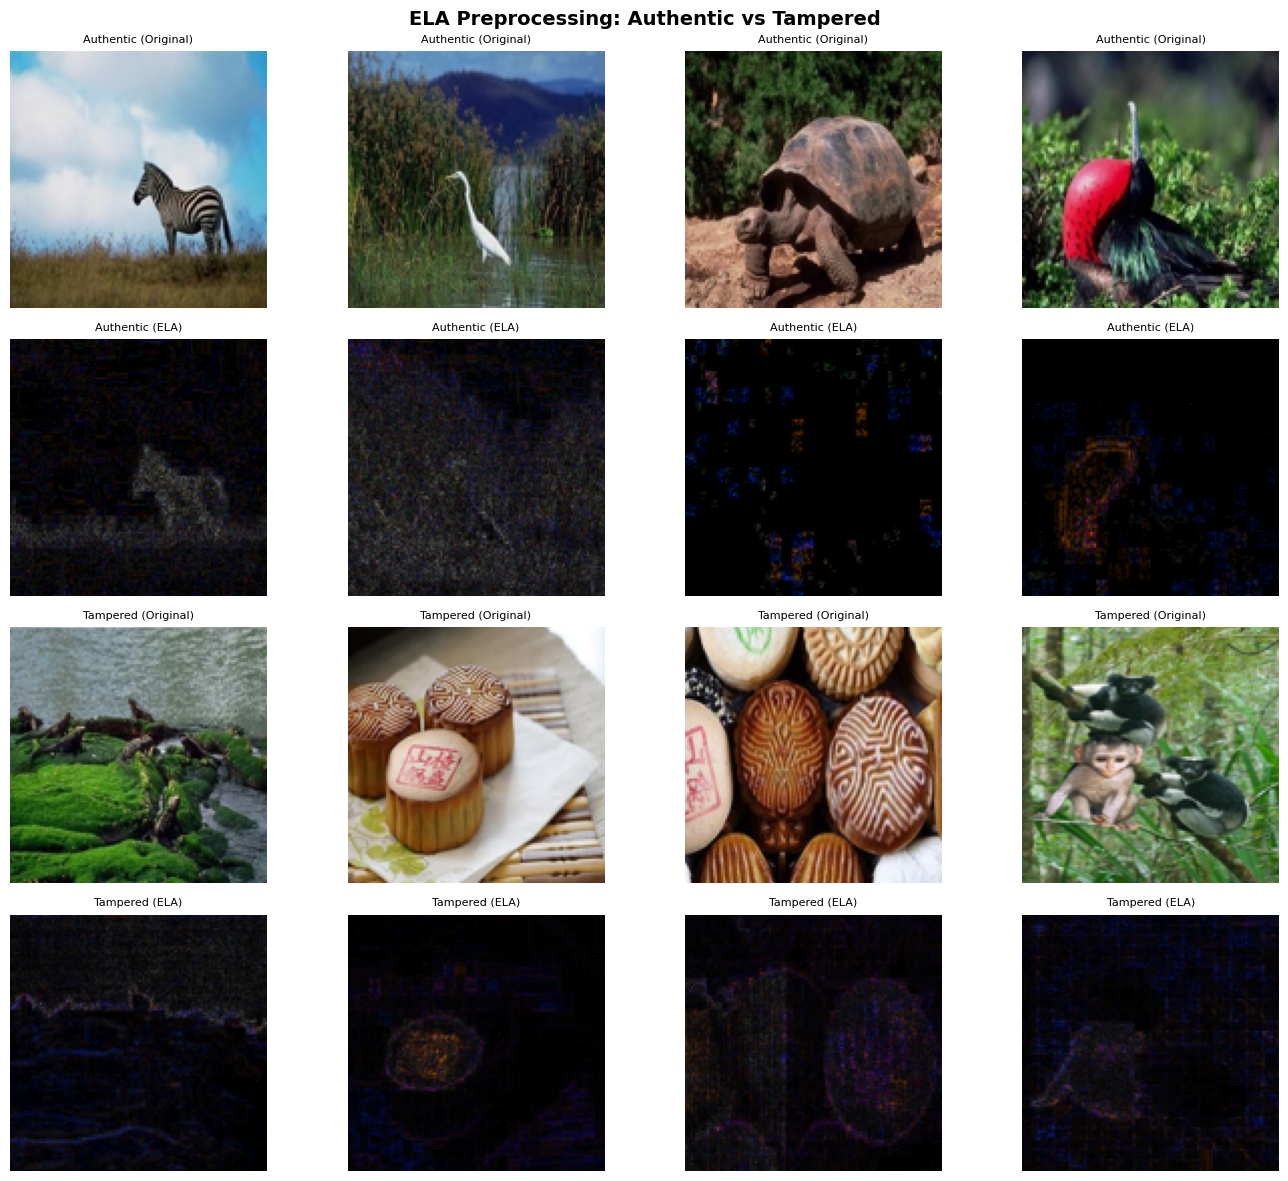

In [5]:
# ============================================================
# 5.1 — ELA Visualization: Authentic vs Tampered (NEW)
# ============================================================

def visualize_ela_samples(paths, labels, n_samples=4):
    """Show original images alongside their ELA maps."""
    au_idx = [i for i, l in enumerate(labels) if l == 0][:n_samples]
    tp_idx = [i for i, l in enumerate(labels) if l == 1][:n_samples]

    fig, axes = plt.subplots(4, n_samples, figsize=(3.5 * n_samples, 12))
    fig.suptitle('ELA Preprocessing: Authentic vs Tampered', fontsize=14, fontweight='bold')

    for col, idx in enumerate(au_idx):
        orig = Image.open(paths[idx]).convert('RGB').resize(IMAGE_SIZE)
        ela = compute_ela(paths[idx])
        axes[0, col].imshow(orig)
        axes[0, col].set_title('Authentic (Original)', fontsize=8)
        axes[0, col].axis('off')
        if ela:
            axes[1, col].imshow(ela.resize(IMAGE_SIZE))
        axes[1, col].set_title('Authentic (ELA)', fontsize=8)
        axes[1, col].axis('off')

    for col, idx in enumerate(tp_idx):
        orig = Image.open(paths[idx]).convert('RGB').resize(IMAGE_SIZE)
        ela = compute_ela(paths[idx])
        axes[2, col].imshow(orig)
        axes[2, col].set_title('Tampered (Original)', fontsize=8)
        axes[2, col].axis('off')
        if ela:
            axes[3, col].imshow(ela.resize(IMAGE_SIZE))
        axes[3, col].set_title('Tampered (ELA)', fontsize=8)
        axes[3, col].axis('off')

    plt.tight_layout()
    plt.show()

visualize_ela_samples(all_paths, all_labels, n_samples=4)

In [6]:
# ============================================================
# 5.2 — Process All Images Through ELA Pipeline
# ============================================================

X = []
Y = []
skipped = 0

print('Processing images through ELA pipeline...')
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths), desc='ELA Processing'):
    img = prepare_image(path)
    if img is not None:
        X.append(img)
        Y.append(label)
    else:
        skipped += 1

print(f'\nSuccessfully processed: {len(X)}, Skipped: {skipped}')

X, Y = shuffle(X, Y, random_state=SEED)
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)

print(f'Feature array shape: {X.shape}')
print(f'Label distribution: Authentic={np.sum(Y==0)}, Tampered={np.sum(Y==1)}')

Processing images through ELA pipeline...


ELA Processing:   0%|          | 0/12614 [00:00<?, ?it/s]


Successfully processed: 12614, Skipped: 0
Feature array shape: (12614, 128, 128, 3)
Label distribution: Authentic=7491, Tampered=5123


---

## 6. Data Splitting

**CHANGED in vR.1.1:** Proper 3-way stratified split.

| Split | Purpose | Usage |
|-------|---------|-------|
| Train (70%) | Model training | Gradient updates |
| Validation (15%) | Early stopping | Model selection only |
| Test (15%) | Final evaluation | **Never seen during training or model selection** |

**NEW in vR.1.3:** After splitting, compute class weights from the training set to address the 1.46:1 class imbalance (5,243 Au vs 3,586 Tp).

In [7]:
# ============================================================
# 6.1 — Train / Validation / Test Split + Class Weights (CHANGED)
# ============================================================

Y_onehot = to_categorical(Y, num_classes=2)

# Step 1: Split off test set
X_temp, X_test, Y_temp_oh, Y_test_oh, Y_temp_int, Y_test_int = train_test_split(
    X, Y_onehot, Y,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=Y
)

# Step 2: Split remaining into train and validation
val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, Y_train, Y_val, Y_train_int, Y_val_int = train_test_split(
    X_temp, Y_temp_oh, Y_temp_int,
    test_size=val_frac,
    random_state=SEED,
    stratify=Y_temp_int
)

total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
del X, Y_onehot, X_temp, Y_temp_oh, Y_temp_int

print(f'Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/total:.0%})')
print(f'Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/total:.0%})')
print(f'Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/total:.0%})')
print(f'\nTrain:  Au={np.sum(Y_train[:,0]==1)}, Tp={np.sum(Y_train[:,1]==1)}')
print(f'Val:    Au={np.sum(Y_val[:,0]==1)}, Tp={np.sum(Y_val[:,1]==1)}')
print(f'Test:   Au={np.sum(Y_test_oh[:,0]==1)}, Tp={np.sum(Y_test_oh[:,1]==1)}')

# NEW in vR.1.3: Compute class weights from training set
class_weights_array = compute_class_weight('balanced', classes=np.array([0, 1]), y=Y_train_int)
CLASS_WEIGHT_DICT = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}
print(f'\n--- NEW in vR.1.3 ---')
print(f'Class weights (inverse-frequency balanced):')
print(f'  Authentic (0): {CLASS_WEIGHT_DICT[0]:.4f}')
print(f'  Tampered  (1): {CLASS_WEIGHT_DICT[1]:.4f}')
print(f'  Tampered/Authentic ratio: {CLASS_WEIGHT_DICT[1]/CLASS_WEIGHT_DICT[0]:.2f}x')

Training set:   8829 samples (70%)
Validation set: 1892 samples (15%)
Test set:       1893 samples (15%)

Train:  Au=5243, Tp=3586
Val:    Au=1124, Tp=768
Test:   Au=1124, Tp=769

--- NEW in vR.1.3 ---
Class weights (inverse-frequency balanced):
  Authentic (0): 0.8420
  Tampered  (1): 1.2310
  Tampered/Authentic ratio: 1.46x


---

## 7. Model Architecture

**CHANGED in vR.1.4:** BatchNormalization added after each Conv2D layer.

| # | Layer | Output Shape | Parameters |
|---|-------|-------------|------------|
| 1 | Conv2D(32, 5x5, valid, ReLU) | (124, 124, 32) | 2,432 |
| 2 | **BatchNormalization** | (124, 124, 32) | **128** |
| 3 | Conv2D(32, 5x5, valid, ReLU) | (120, 120, 32) | 25,632 |
| 4 | **BatchNormalization** | (120, 120, 32) | **128** |
| 5 | MaxPooling2D(2x2) | (60, 60, 32) | 0 |
| 6 | Dropout(0.25) | (60, 60, 32) | 0 |
| 7 | Flatten | (115,200) | 0 |
| 8 | Dense(256, ReLU) | (256) | 29,491,456 |
| 9 | Dropout(0.5) | (256) | 0 |
| 10 | Dense(2, Softmax) | (2) | 514 |

**Total: ~29.5M parameters** (+256 from 2x BatchNorm)

### What BatchNormalization Does

For each Conv2D output channel, BN normalizes activations across the mini-batch:

```
BN(x) = gamma * (x - mean(x)) / sqrt(var(x) + epsilon) + beta
```

- **gamma, beta**: Learnable scale and shift (64 params per BN = 32 channels x 2)
- **Running mean/var**: Tracked during training, used during inference
- **Effect**: Smoother loss landscape, faster convergence, mild regularization

In [8]:
# ============================================================
# 7.1 — Build CNN Model (CHANGED: BatchNormalization added)
# ============================================================

def build_model(input_shape=(128, 128, 3)):
    """CNN architecture with BatchNormalization after each Conv2D.

    Change from vR.1.3: Added BatchNormalization() after each Conv2D.
    This is the ONLY architectural change in vR.1.4.
    """
    model = Sequential([
        Conv2D(32, (5, 5), activation='relu', padding='valid', input_shape=input_shape),
        BatchNormalization(),  # NEW in vR.1.4
        Conv2D(32, (5, 5), activation='relu', padding='valid'),
        BatchNormalization(),  # NEW in vR.1.4
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

I0000 00:00:1773521823.875848      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 120, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,520,290 (112.61 MB)

 Trainable params: 29,520,162 (112.61 MB)

 Non-trainable params: 128 (512.00 B)

---

## 8. Training Pipeline

**Inherits from vR.1.4:** Class weights + BatchNormalization retained. **NEW: LR Scheduler added.**

- Optimizer: Adam (lr=0.0001 initial) — frozen
- Loss: categorical_crossentropy — frozen
- Early stopping: val_accuracy, patience=5, restore_best_weights — frozen
- Batch size: 32 — frozen
- Class weights: inverse-frequency balanced (from vR.1.3)
- BatchNormalization after each Conv2D (from vR.1.4)
- **NEW: ReduceLROnPlateau** — monitors val_loss, halves LR after 3 epochs of no improvement, floor at 1e-6

### LR Scheduler Strategy

The scheduler's patience (3) is shorter than early stopping's patience (5). This means:
1. If val_loss plateaus, LR halves first (giving the model a chance to improve at lower LR)
2. If no improvement even after LR reduction, early stopping eventually triggers
3. This allows longer, more productive training than fixed LR

In [9]:
# ============================================================
# 8.1 — Compile Model (UNCHANGED)
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print('Model compiled (unchanged from baseline).')

Model compiled (unchanged from baseline).


In [10]:
# ============================================================
# 8.2 — Train the Model (CHANGED: add LR scheduler)
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# NEW in vR.1.5: ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print(f'Training on {X_train.shape[0]} samples, validating on {X_val.shape[0]} samples')
print(f'Test set ({X_test.shape[0]} samples) held out — NOT used during training')
print(f'Batch size: {BATCH_SIZE}, Max epochs: {EPOCHS}')
print(f'Class weights: Au={CLASS_WEIGHT_DICT[0]:.4f}, Tp={CLASS_WEIGHT_DICT[1]:.4f}')
print(f'LR Scheduler: ReduceLROnPlateau(val_loss, factor=0.5, patience=3, min_lr=1e-6)')
print('=' * 60)

history = model.fit(
    X_train, Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, lr_scheduler],  # NEW: lr_scheduler added
    class_weight=CLASS_WEIGHT_DICT,  # from vR.1.3
    verbose=1
)

print(f'\nTraining complete. Epochs run: {len(history.history["loss"])}')

Training on 8829 samples, validating on 1892 samples
Test set (1893 samples) held out — NOT used during training
Batch size: 32, Max epochs: 50
Class weights: Au=0.8420, Tp=1.2310
LR Scheduler: ReduceLROnPlateau(val_loss, factor=0.5, patience=3, min_lr=1e-6)
Epoch 1/50


I0000 00:00:1773521832.427021     133 service.cc:152] XLA service 0x7dfc34002f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773521832.427082     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773521832.932291     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/276 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6409 - loss: 4.2932 - precision: 0.6409 - recall: 0.6409

I0000 00:00:1773521838.584205     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


276/276 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.7677 - loss: 1.0747 - precision: 0.7677 - recall: 0.7677 - val_accuracy: 0.4059 - val_loss: 14.7414 - val_precision: 0.4059 - val_recall: 0.4059 - learning_rate: 1.0000e-04
Epoch 2/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8799 - loss: 0.3036 - precision: 0.8799 - recall: 0.8799 - val_accuracy: 0.7363 - val_loss: 3.8575 - val_precision: 0.7363 - val_recall: 0.7363 - learning_rate: 1.0000e-04
Epoch 3/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9023 - loss: 0.2473 - precision: 0.9023 - recall: 0.9023 - val_accuracy: 0.8626 - val_loss: 0.2893 - val_precision: 0.8626 - val_recall: 0.8626 - learning_rate: 1.0000e-04
Epoch 4/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9114 - loss: 0.2053 - precision: 0.9114 - recall: 0.9114 - val_accuracy: 0.8832 - val_loss: 0.2838 - val_precision: 0.8832 - val_recall: 0.8832 - learning_rate: 1.0000e-04
Epoch 5/50
276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step 

---

## 9. Test Set Evaluation

**CHANGED in vR.1.1:** All metrics computed on the **held-out test set** that was never used during training or model selection.

Metrics reported:
- Per-class Precision, Recall, F1 (Authentic and Tampered separately)
- Macro-average Precision, Recall, F1
- ROC-AUC
- Confusion matrix

In [11]:
# ============================================================
# 9.1 — Test Set Predictions and Metrics (CHANGED)
# ============================================================

y_test_probs = model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_probs, axis=1)
y_test_true = Y_test_int

test_acc = accuracy_score(y_test_true, y_test_pred)

# Per-class metrics
test_prec_per = precision_score(y_test_true, y_test_pred, average=None)
test_rec_per = recall_score(y_test_true, y_test_pred, average=None)
test_f1_per = f1_score(y_test_true, y_test_pred, average=None)

# Macro average
test_prec_macro = precision_score(y_test_true, y_test_pred, average='macro')
test_rec_macro = recall_score(y_test_true, y_test_pred, average='macro')
test_f1_macro = f1_score(y_test_true, y_test_pred, average='macro')

# ROC-AUC (NEW in vR.1.1)
fpr, tpr, _ = roc_curve(y_test_true, y_test_probs[:, 1])
test_roc_auc = auc(fpr, tpr)

print('=' * 60)
print(f'  TEST SET EVALUATION — {VERSION}')
print('=' * 60)
print(f'  Accuracy:       {test_acc:.4f}  ({test_acc*100:.2f}%)')
print()
print(f'  {"":20s} {"Authentic":>10s} {"Tampered":>10s} {"Macro":>10s}')
print(f'  {"-"*55}')
print(f'  {"Precision":20s} {test_prec_per[0]:>10.4f} {test_prec_per[1]:>10.4f} {test_prec_macro:>10.4f}')
print(f'  {"Recall":20s} {test_rec_per[0]:>10.4f} {test_rec_per[1]:>10.4f} {test_rec_macro:>10.4f}')
print(f'  {"F1 Score":20s} {test_f1_per[0]:>10.4f} {test_f1_per[1]:>10.4f} {test_f1_macro:>10.4f}')
print()
print(f'  ROC-AUC:        {test_roc_auc:.4f}')
print('=' * 60)
print(f'\nPaper claims: Acc=96.21%, Prec=98.58%, Rec=92.36%, F1=95.37%')

  TEST SET EVALUATION — vR.1.5
  Accuracy:       0.8896  (88.96%)

                        Authentic   Tampered      Macro
  -------------------------------------------------------
  Precision                0.9403     0.8279     0.8841
  Recall                   0.8692     0.9194     0.8943
  F1 Score                 0.9034     0.8712     0.8873

  ROC-AUC:        0.9560

Paper claims: Acc=96.21%, Prec=98.58%, Rec=92.36%, F1=95.37%


In [12]:
# ============================================================
# 9.2 — Detailed Classification Report
# ============================================================

print('Detailed Classification Report (Test Set):')
print('-' * 55)
print(classification_report(
    y_test_true, y_test_pred,
    target_names=['Authentic', 'Tampered'],
    digits=4
))

Detailed Classification Report (Test Set):
-------------------------------------------------------
              precision    recall  f1-score   support

   Authentic     0.9403    0.8692    0.9034      1124
    Tampered     0.8279    0.9194    0.8712       769

    accuracy                         0.8896      1893
   macro avg     0.8841    0.8943    0.8873      1893
weighted avg     0.8946    0.8896    0.8903      1893



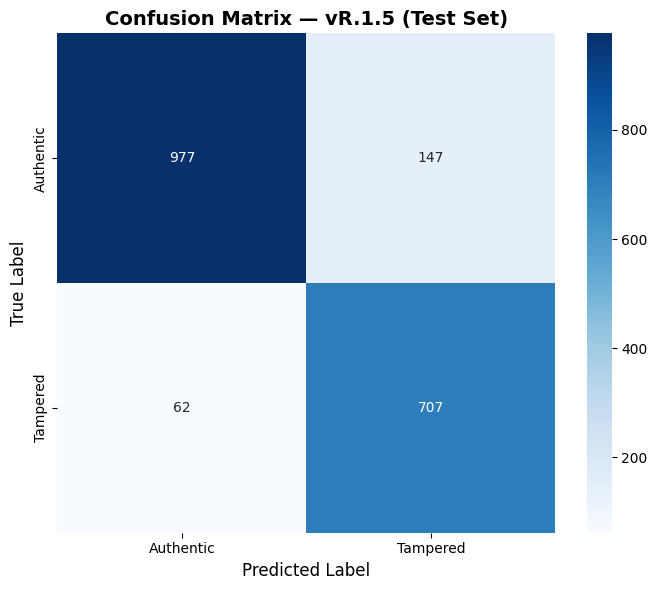

True Negatives  (Au correct):    977
False Positives (Au -> Tp):      147  (FP rate: 13.1%)
False Negatives (Tp -> Au):      62  (FN rate: 8.1%)
True Positives  (Tp correct):    707


In [13]:
# ============================================================
# 9.3 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Tampered'],
            yticklabels=['Authentic', 'Tampered'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {VERSION} (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Au correct):    {tn}')
print(f'False Positives (Au -> Tp):      {fp}  (FP rate: {fp/(tn+fp):.1%})')
print(f'False Negatives (Tp -> Au):      {fn}  (FN rate: {fn/(fn+tp):.1%})')
print(f'True Positives  (Tp correct):    {tp}')

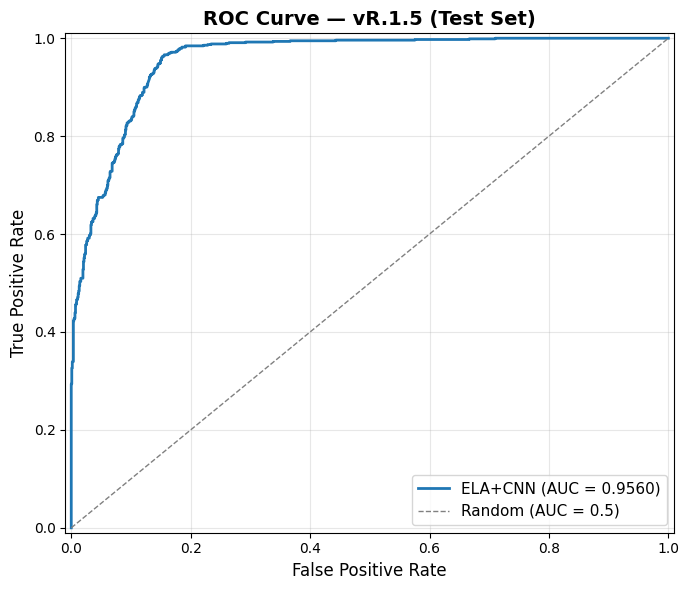

In [14]:
# ============================================================
# 9.4 — ROC Curve (NEW in vR.1.1)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f'ELA+CNN (AUC = {test_roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {VERSION} (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

---

## 10. Results Visualization

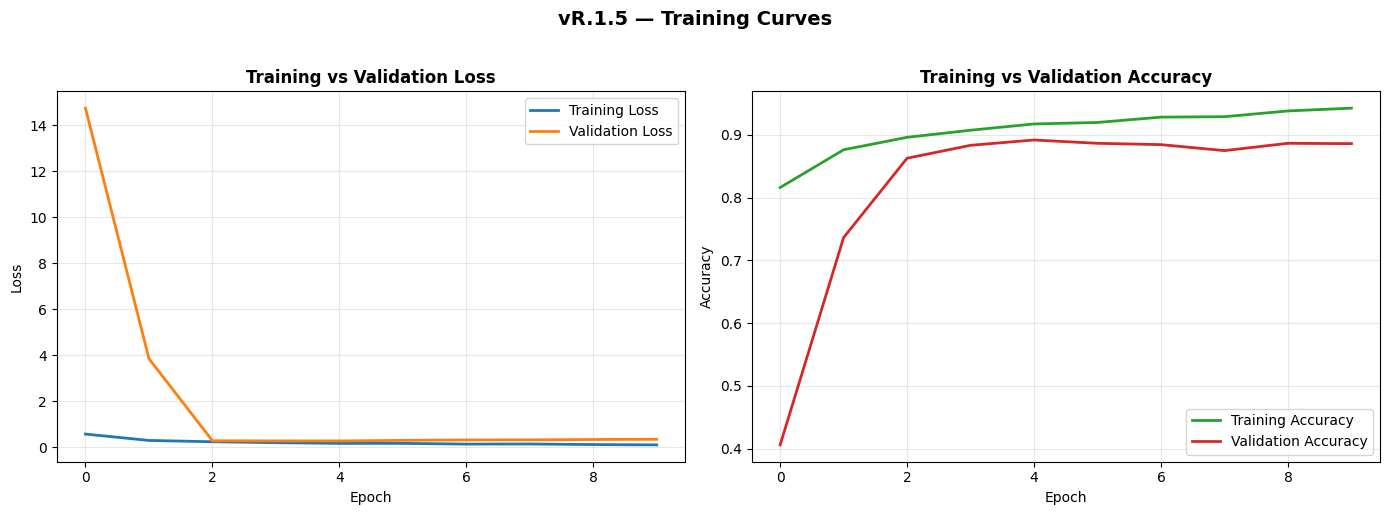

In [15]:
# ============================================================
# 10.1 — Training Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'{VERSION} — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

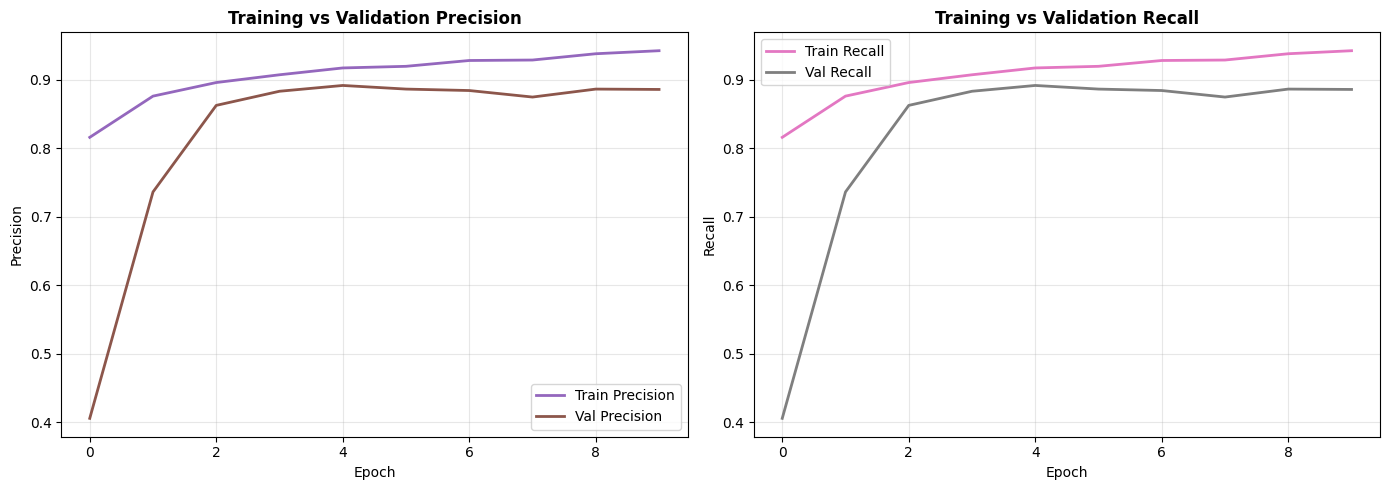

In [16]:
# ============================================================
# 10.2 — Precision / Recall Training Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['precision'], label='Train Precision', color='#9467bd', linewidth=2)
ax1.plot(history.history['val_precision'], label='Val Precision', color='#8c564b', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Precision')
ax1.set_title('Training vs Validation Precision', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['recall'], label='Train Recall', color='#e377c2', linewidth=2)
ax2.plot(history.history['val_recall'], label='Val Recall', color='#7f7f7f', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Recall')
ax2.set_title('Training vs Validation Recall', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

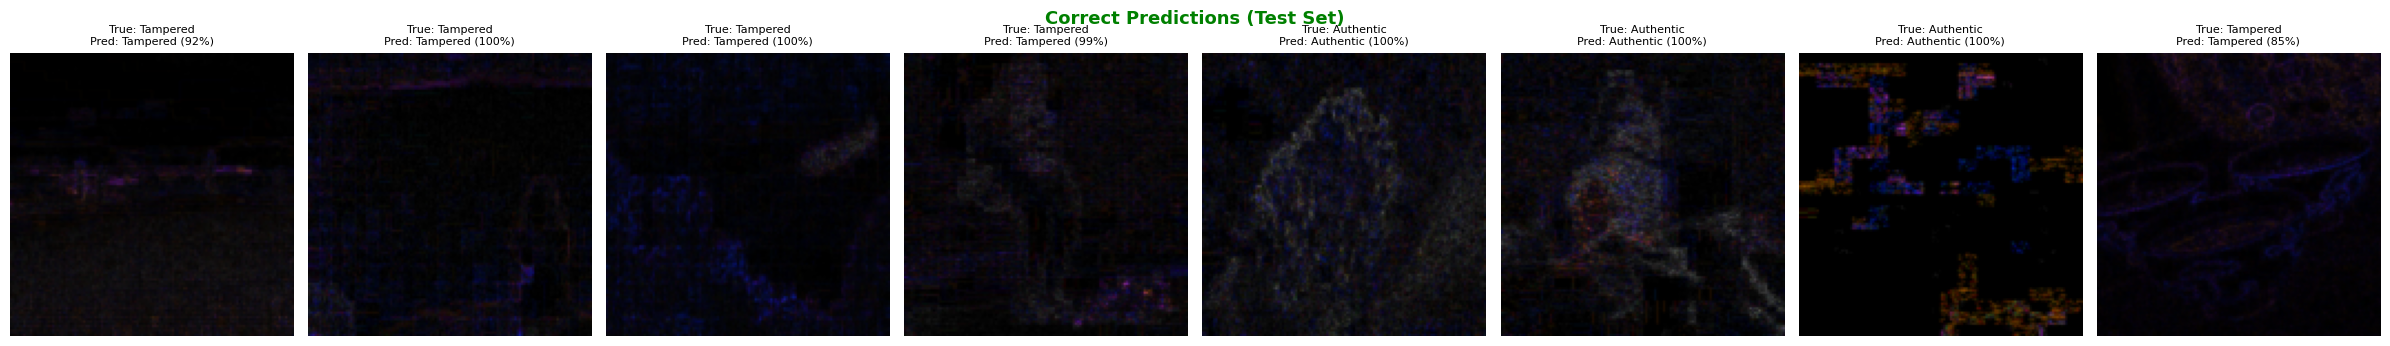

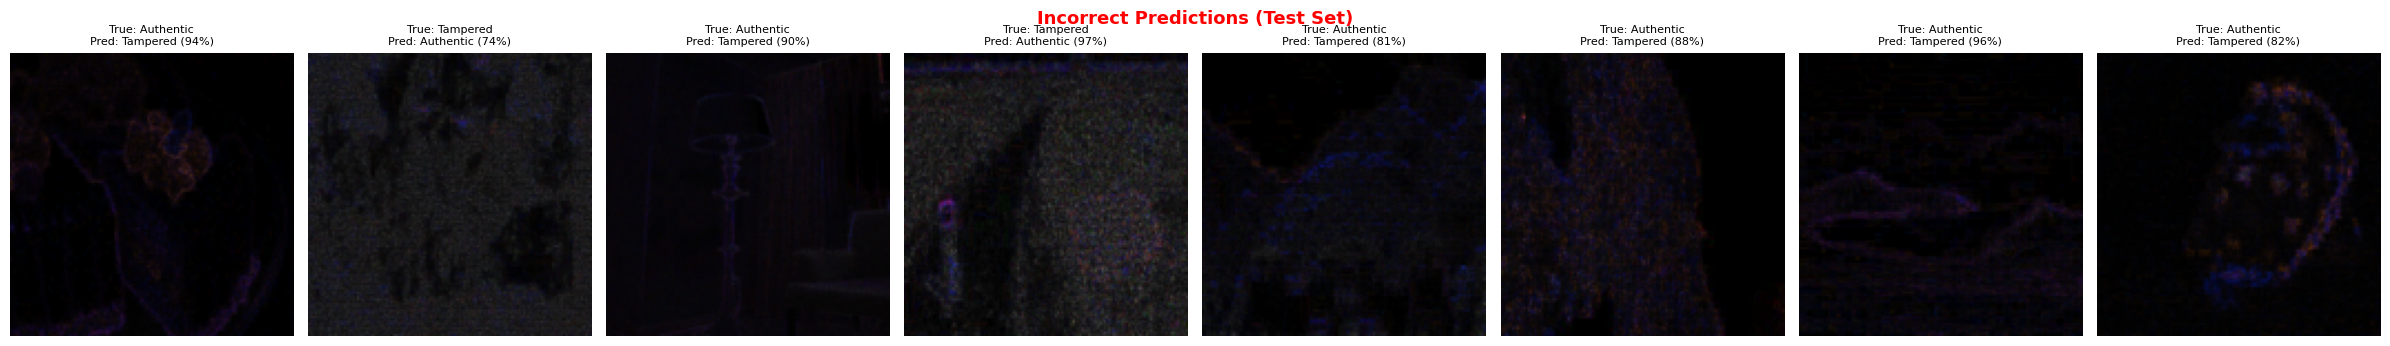

In [17]:
# ============================================================
# 10.3 — Sample Predictions (Test Set)
# ============================================================

def visualize_predictions(X_data, y_true_labels, y_pred_labels, y_pred_probs, n_samples=8):
    """Show sample predictions with confidence scores."""
    class_names = ['Authentic', 'Tampered']
    correct = y_true_labels == y_pred_labels
    incorrect = ~correct

    correct_idx = np.where(correct)[0][:n_samples]
    incorrect_idx = np.where(incorrect)[0][:min(n_samples, np.sum(incorrect))]

    if len(correct_idx) > 0:
        n = min(len(correct_idx), n_samples)
        fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
        fig.suptitle('Correct Predictions (Test Set)', fontsize=13, fontweight='bold', color='green')
        if n == 1: axes = [axes]
        for ax, idx in zip(axes, correct_idx[:n]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]} ({conf:.0%})', fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    if len(incorrect_idx) > 0:
        n = min(len(incorrect_idx), n_samples)
        fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
        fig.suptitle('Incorrect Predictions (Test Set)', fontsize=13, fontweight='bold', color='red')
        if n == 1: axes = [axes]
        for ax, idx in zip(axes, incorrect_idx[:n]):
            ax.imshow(X_data[idx])
            conf = y_pred_probs[idx][y_pred_labels[idx]]
            ax.set_title(f'True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]} ({conf:.0%})', fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

visualize_predictions(X_test, y_test_true, y_test_pred, y_test_probs)

---

## 11. Ablation Comparison

Results tracking table — updated after each run.

In [18]:
# ============================================================
# 11.1 — Ablation Results Tracking
# ============================================================

print('=' * 105)
print(f'  ABLATION STUDY — RESULTS TRACKING TABLE')
print('=' * 105)
print()
print(f'  {"Version":<10} {"Change":<35} {"Test Acc":>9} {"Tp Prec":>8} {"Tp Rec":>7} {"Tp F1":>7} {"Macro F1":>9} {"AUC":>6} {"Epochs":>7}')
print(f'  {"-"*100}')
print(f'  {"vR.1.0":<10} {"Baseline (val metrics)":<35} {"89.89%*":>9} {"0.8279*":>8} {"0.9483*":>7} {"0.8840*":>7} {"0.8972*":>9} {"  ---":>6} {"13 (8)":>7}')
print(f'  {"vR.1.1":<10} {"Eval fix":<35} {"88.38%":>9} {"0.8393":>8} {"0.8830":>7} {"0.8606":>7} {"0.8805":>9} {"0.9601":>6} {"13 (8)":>7}')
print(f'  {"vR.1.2":<10} {"Augmentation (REJECTED)":<35} {"85.53%":>9} {"0.8145":>8} {"0.8336":>7} {"0.8239":>7} {"0.8505":>9} {"0.9011":>6} {" 6 (1)":>7}')
print(f'  {"vR.1.3":<10} {"Class weights":<35} {"89.17%":>9} {"0.8431":>8} {"0.9012":>7} {"0.8712":>7} {"0.8889":>9} {"0.9580":>6} {"14 (9)":>7}')
print(f'  {"vR.1.4":<10} {"BatchNorm (NEUTRAL)":<35} {"88.75%":>9} {"0.8240":>8} {"0.9194":>7} {"0.8691":>7} {"0.8852":>9} {"0.9536":>6} {" 8 (3)":>7}')
print(f'  {"vR.1.5":<10} {"LR Scheduler (this run)":<35} {test_acc:>8.2%} {test_prec_per[1]:>8.4f} {test_rec_per[1]:>7.4f} {test_f1_per[1]:>7.4f} {test_f1_macro:>9.4f} {test_roc_auc:>6.4f} {str(len(history.history["loss"])):>7}')
print()
print('  * vR.1.0 metrics are on validation set (biased). Not directly comparable.')
print('  vR.1.2 augmentation was REJECTED (branched from vR.1.1 for vR.1.3).')
print('=' * 105)

  ABLATION STUDY — RESULTS TRACKING TABLE

  Version    Change                               Test Acc  Tp Prec  Tp Rec   Tp F1  Macro F1    AUC  Epochs
  ----------------------------------------------------------------------------------------------------
  vR.1.0     Baseline (val metrics)                89.89%*  0.8279* 0.9483* 0.8840*   0.8972*    ---  13 (8)
  vR.1.1     Eval fix                               88.38%   0.8393  0.8830  0.8606    0.8805 0.9601  13 (8)
  vR.1.2     Augmentation (REJECTED)                85.53%   0.8145  0.8336  0.8239    0.8505 0.9011   6 (1)
  vR.1.3     Class weights                          89.17%   0.8431  0.9012  0.8712    0.8889 0.9580  14 (9)
  vR.1.4     BatchNorm (NEUTRAL)                    88.75%   0.8240  0.9194  0.8691    0.8852 0.9536   8 (3)
  vR.1.5     LR Scheduler (this run)               88.96%   0.8279  0.9194  0.8712    0.8873 0.9560      10

  * vR.1.0 metrics are on validation set (biased). Not directly comparable.
  vR.1.2 augmen

---

## 12. Discussion

### Change in This Version

**ReduceLROnPlateau** learning rate scheduler was added:

```
ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # halve LR
    patience=3,        # wait 3 epochs of no improvement
    min_lr=1e-6        # floor
)
```

### Why This Change

vR.1.4 (BatchNorm) showed training instability:
- **Epoch 1 catastrophe:** val_loss = 16.13 (BN warmup with high LR)
- **Very short training:** only 8 epochs total (best at epoch 3)
- Model converged too fast to a potentially suboptimal solution

ReduceLROnPlateau addresses this by:
1. **Automatically reducing LR** when val_loss stops improving
2. **Dampening instability** — if val_loss spikes (BN warmup), LR is quickly halved
3. **Enabling fine-grained convergence** — lower LR allows settling into better minima
4. **Extending training** — LR reductions give the model more epochs before early stopping

### Interaction with Existing Components

- **BatchNorm (vR.1.4):** Complementary. BN smooths the loss landscape; the scheduler adapts step size to that landscape.
- **Class weights (vR.1.3):** No interference. Class weights modify the loss magnitude; the scheduler monitors loss trends, not absolute values.
- **Early stopping (patience=5):** Scheduler patience (3) < ES patience (5), so LR reduces before training stops. This gives the model at least one LR reduction opportunity.

### Expected Impact

- Longer training (15–30 epochs vs vR.1.4's 8)
- Reduced epoch 1 instability (LR drops after spike)
- Better final metrics (+0.5–2pp accuracy)
- Smoother training curves

### Next Version: vR.1.6

The next ablation will add a **3rd Conv2D(64, 3×3) layer + MaxPool** before Flatten, increasing the model's feature extraction depth while reducing the Flatten→Dense size.

In [19]:
# ============================================================
# 12.1 — Save Model Weights
# ============================================================

model.save(f'{VERSION}_ela_cnn_model.keras')
print(f'Model saved: {VERSION}_ela_cnn_model.keras')
print(f'Model parameters: {model.count_params():,}')

Model saved: vR.1.5_ela_cnn_model.keras
Model parameters: 29,520,290
